In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as sstat
import scipy.signal as ssig

# import ephys_unit_analysis as ena
import mz_ephys_unit_analysis as mz_ena
import mz_unit_dur_freq as mz_udf

import sys
sys.path.append(r'U:/Data_Analysis/kumar603/LemonPy')
from LemonPy.utils_vmk import set_pub_plots
set_pub_plots()

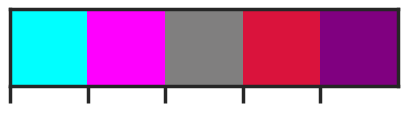

In [2]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

# First, load in the previously saved dataFrame

In [3]:
final_df = pd.read_parquet(r"U:\Papers\FX Behavior paper\data\final_V1HPC_OperantNovel_psth.parquet")
final_df.head()

,stim_id,times,cuid,depth,Hz,zscore,ztc,region,group,cc,et,r_groups,visRes
0,0,0.00,CC067431_HP2_248,740,2.543532,-0.865956,-2.264451,hippo,FX,CC067431,CC067431_HP2,0,yes
1,0,0.01,CC067431_HP2_248,740,2.918449,-0.811714,-1.841745,hippo,FX,CC067431,CC067431_HP2,0,yes
2,0,0.02,CC067431_HP2_248,740,3.278977,-0.759553,-1.435263,hippo,FX,CC067431,CC067431_HP2,0,yes
3,0,0.03,CC067431_HP2_248,740,3.651381,-0.705674,-1.015391,hippo,FX,CC067431,CC067431_HP2,0,yes
4,0,0.04,CC067431_HP2_248,740,4.026938,-0.651339,-0.591964,hippo,FX,CC067431,CC067431_HP2,0,yes


In [4]:
final_df.stim_id.unique()

array([0, 1, 2, 9], dtype=int64)

---

### Now choose the reward situation you want
This requires a __`user input`__ to run

In [5]:
rew_to_plot = input('What reward training stage (rew, rew2, unrew, novel): ')
region = 'v1'

if rew_to_plot == 'rew':
    reward_df = final_df[final_df['stim_id'] == 0]
    plt_title = 'Go+'
elif rew_to_plot == 'rew2':
    reward_df = final_df[final_df['stim_id'] == 1]
    plt_title = 'Go-'
elif rew_to_plot == 'unrew':
    reward_df = final_df[final_df['stim_id'] == 2]
    plt_title = 'No-Go'
elif rew_to_plot == 'novel':
    reward_df = final_df[final_df['stim_id'] == 9]
    plt_title = 'Novel'
    
V1_all_groups_df = reward_df[reward_df['region'] == region]

What reward training stage (rew, rew2, unrew, novel):  rew


# Selecting only the visually responsive units...

In [6]:
vis_resp_df = V1_all_groups_df[V1_all_groups_df.visRes=='yes']

# Separating by group and moving to arrays

In [7]:
group_A_df = vis_resp_df[vis_resp_df['group'] == 'WT']
group_B_df = vis_resp_df[vis_resp_df['group'] == 'FX']

A_array = np.array(group_A_df.pivot(index='cuid', columns='times', values='zscore'))
print(A_array.shape) #this is [units x times] and the values are above

B_array = np.array(group_B_df.pivot(index='cuid', columns='times', values='zscore'))
print(B_array.shape) #this is [units x times] and the values are above

(477, 300)
(334, 300)


---

# Quantifying the oscillation duration and frequency

In [8]:
num_cycles_required = 2

durationA = []
indA = []
for unit in range(A_array.shape[0]):
    yy = A_array[unit]
    dur, peak_ind = mz_udf._duration_peaks_unit(yy)
    if len(peak_ind) >= num_cycles_required:
        durationA.append(dur)
        indA.append(peak_ind)

durationB = []
indB = []
for unit in range(B_array.shape[0]):
    yy = B_array[unit]
    dur, peak_ind = mz_udf._duration_peaks_unit(yy)
    if len(peak_ind) >= num_cycles_required:
        durationB.append(dur)
        indB.append(peak_ind)

In [9]:
indA_array = np.concatenate(indA, axis=0)
indB_array = np.concatenate(indB, axis=0)

---

# Oscillation duration

In [10]:
durA_df = pd.DataFrame(tuple(zip(durationA,(['WT']*len(durationA)))),columns=['dur','group'])
durB_df = pd.DataFrame(tuple(zip(durationB,(['FX']*len(durationB)))),columns=['dur','group'])
all_dur_df=pd.concat([durA_df,durB_df])
all_dur_df.head()

,dur,group
0,NaN,WT
1,0.22,WT
2,NaN,WT
3,NaN,WT
4,0.27,WT


In [11]:
#removes the NaN values from the above dataframe
all_dur_df=all_dur_df[~all_dur_df.dur.isna()]
all_dur_df.shape

(400, 2)

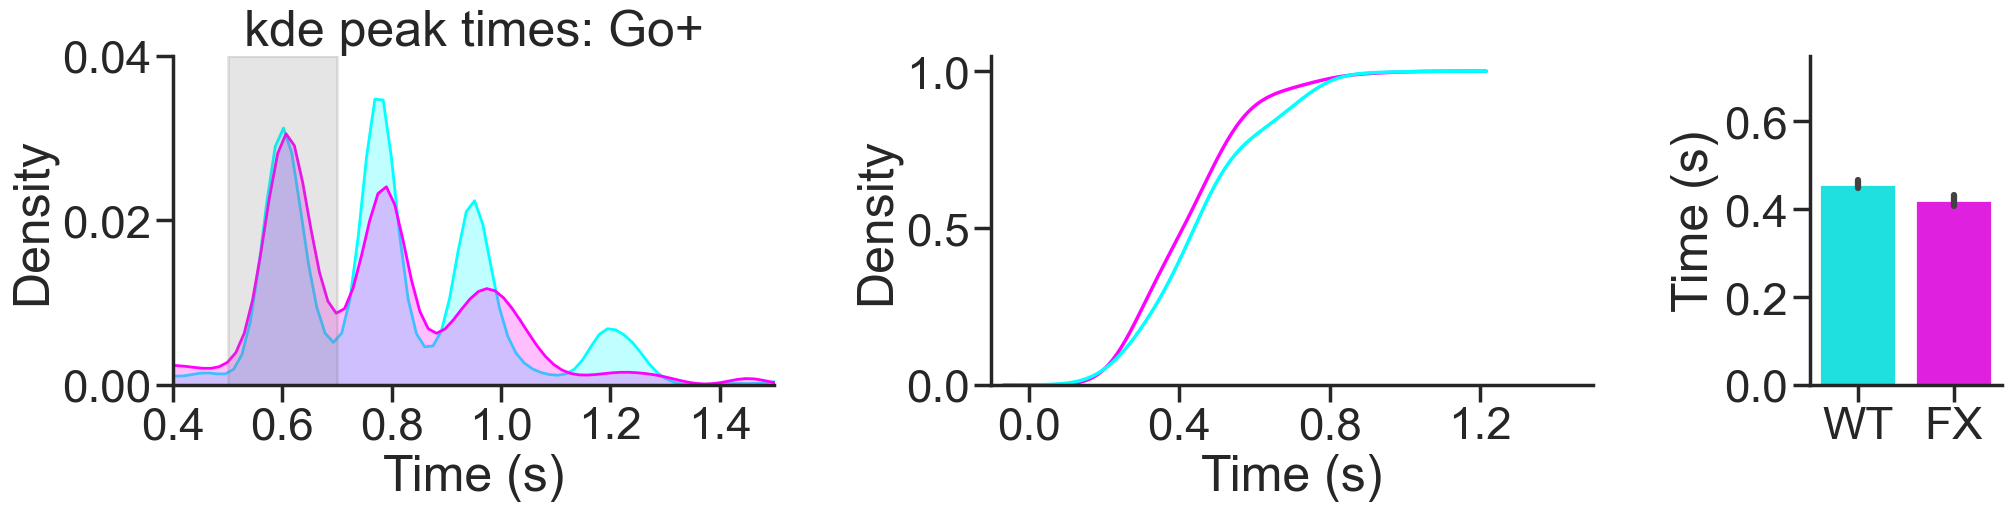

In [12]:
fig = plt.figure(figsize=(21,6))
gs = fig.add_gridspec(1,5)
ax0 = fig.add_subplot(gs[0:2])
ax1 = fig.add_subplot(gs[2:4])
ax2 = fig.add_subplot(gs[4])

sns.kdeplot(indA_array, bw_method=0.07, color='cyan', fill=True, ax=ax0)
sns.kdeplot(indB_array, bw_method=0.07, color='magenta', fill=True, ax=ax0)
sns.kdeplot(data=all_dur_df, x="dur", hue="group",
            cumulative=True, common_norm=False, common_grid=True, bw_method=0.5, legend=False, ax=ax1)
sns.barplot(data=all_dur_df, x='group', y='dur', order=["WT","FX"], errorbar=('ci', 68), ax=ax2)

ax0.set_title(str('kde peak times: '+plt_title))
ax0.set_xlim([40,150])
ax0.set_xticks(ticks=[40,60,80,100,120,140], labels=[0.4,0.6,0.8,1.0,1.2,1.4])
ax0.set_yticks(ticks=[0,0.02,0.04])
ax0.set_xlabel('Time (s)')
ax0.axvspan(50,70, color='grey', alpha=0.2)

ax1.set_xlabel('Time (s)')
ax1.set_xticks([0,0.4,0.8,1.2])
ax1.set_xlim([-0.1,1.5])

ax2.set_ylabel('Time (s)')
ax2.set_xlabel('')
ax2.set_xticklabels(['WT','FX'])
ax2.set_yticks(ticks=[0,0.2,0.4,0.6])
ax2.set_ylim([0,0.75])

plt.tight_layout()
sns.despine()
# Change the end of this next line with a new file name!!
# plt.savefig(rf'U:\Papers\FX Behavior paper\Figures\hpc_figures\units\freq_dur\{rew_to_plot}_{region}_durationPlots.pdf', transparent=True)
plt.show()

# Run the stats on the oscillation duration

In [13]:
result = sstat.ks_2samp(all_dur_df[all_dur_df['group']=='WT'].dur, all_dur_df[all_dur_df['group']=='FX'].dur)
print('Oscillation Duration')
print(plt_title)
print('WT units: {0} --- FX units: {1}'.format(len(indA),len(indB)))
print(result)

Oscillation Duration
Go+
WT units: 375 --- FX units: 208
KstestResult(statistic=0.15765018254231664, pvalue=0.019413426406873543, statistic_location=0.41000000000000003, statistic_sign=-1)


In [14]:
print('Oscillation Duration')
print(plt_title)

print('Mean of WT: {0}'.format(np.mean(all_dur_df[all_dur_df['group']=='WT'].dur)))
print('Mean of FX: {0}'.format(np.mean(all_dur_df[all_dur_df['group']=='FX'].dur)))

result = sstat.ttest_ind(all_dur_df[all_dur_df['group']=='WT'].dur, all_dur_df[all_dur_df['group']=='FX'].dur)
print(result)

Oscillation Duration
Go+
Mean of WT: 0.457824427480916
Mean of FX: 0.42101449275362324
TtestResult(statistic=2.332827527292311, pvalue=0.020154815253304387, df=398.0)


---

# Quantify the unit oscillation frequency

In [15]:
freqA = [1/np.diff(i)*100+1 for i in indA]
freqB = [1/np.diff(i)*100+1 for i in indB]
mean_freqA = [np.mean(1/np.diff(i)*100)+1 for i in indA]
mean_freqB = [np.mean(1/np.diff(i)*100)+1 for i in indB]

In [16]:
freqA_df = pd.DataFrame(tuple(zip(freqA,(['WT']*len(mean_freqA)),mean_freqA)),columns=['freq', 'group', 'mean_cyc'])
freqB_df = pd.DataFrame(tuple(zip(freqB,(['FX']*len(mean_freqB)),mean_freqB)),columns=['freq', 'group', 'mean_cyc'])
all_freq_df=pd.concat([freqA_df,freqB_df])

all_freq_df['cyc0'] = all_freq_df.freq.str[0] #this is the 1-2 peak cycle
all_freq_df['cyc1'] = all_freq_df.freq.str[1] #this is the 2-3 peak cycle
all_freq_df['cyc2'] = all_freq_df.freq.str[2] #this is the 3-4 peak cycle

all_freq_df.head()

,freq,group,mean_cyc,cyc0,cyc1,cyc2
0,"[10.090909090909092, 1.5434782608695652, 10.09...",WT,7.241765,10.090909,1.543478,10.090909
1,[9.333333333333332],WT,9.333333,9.333333,NaN,NaN
2,[3.7777777777777777],WT,3.777778,3.777778,NaN,NaN
3,[1.8130081300813008],WT,1.813008,1.813008,NaN,NaN
4,[5.761904761904762],WT,5.761905,5.761905,NaN,NaN


## choose what to plot (which freq cycle)

In [17]:


which_freq_plt = 'mean_cyc' # mean_cyc, cyc0, cyc1, cyc2


# removes the NaN values from the above dataframe
all_freq_df=all_freq_df[~all_freq_df[which_freq_plt].isna()]
all_freq_df.shape

(583, 6)

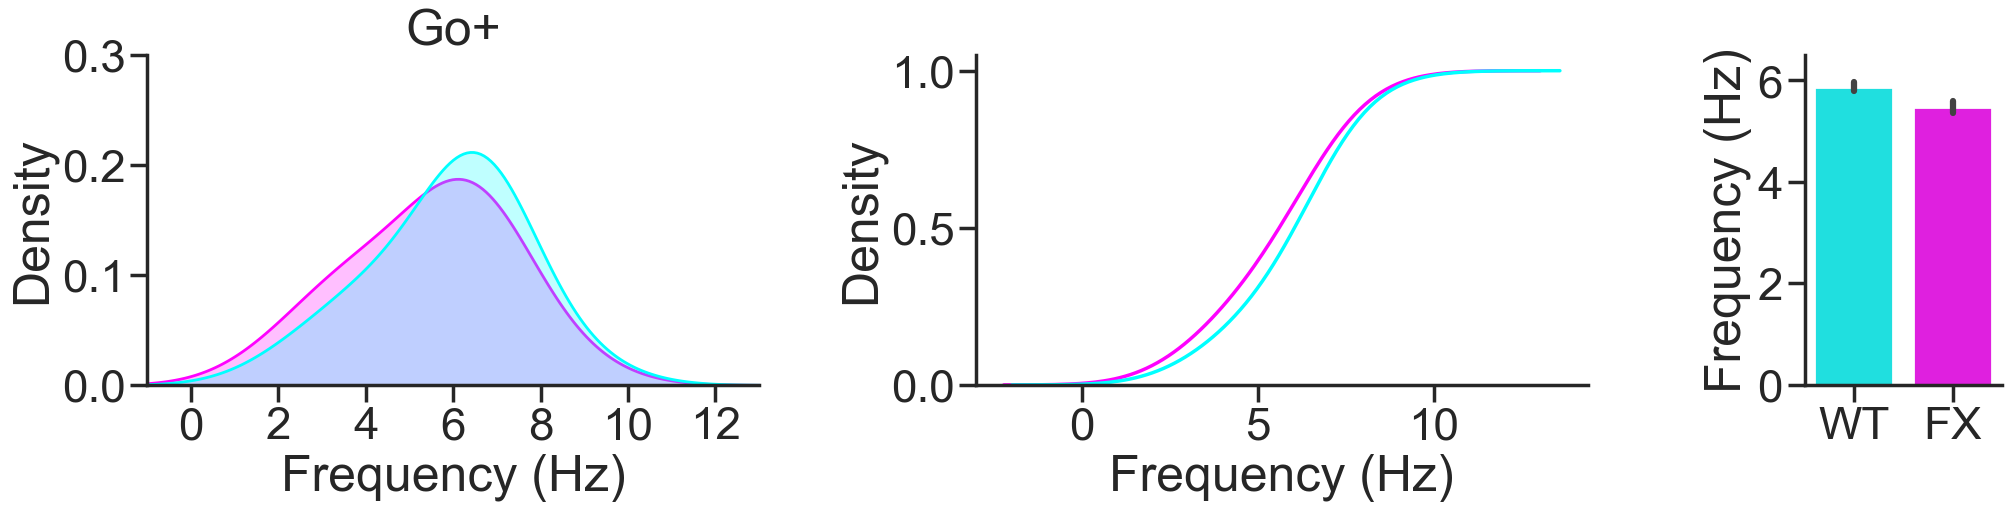

In [18]:
fig = plt.figure(figsize=(21,6))
gs = fig.add_gridspec(1,5)
ax0 = fig.add_subplot(gs[0:2])
ax1 = fig.add_subplot(gs[2:4])
ax2 = fig.add_subplot(gs[4])
sns.kdeplot(data=all_freq_df, x=which_freq_plt, hue="group",
            cumulative=False, common_norm=False, bw_method=0.7, fill=True, legend=False, ax=ax0)
sns.kdeplot(data=all_freq_df, x=which_freq_plt, hue="group",
            cumulative=True, common_norm=False, bw_method=0.7, legend=False, ax=ax1)
sns.barplot(data=all_freq_df, x='group', y=which_freq_plt, order=["WT","FX"], errorbar=('ci', 68), ax=ax2)

ax0.set_title(plt_title)
ax0.set_xlabel('Frequency (Hz)')
ax0.set_xticks([0,2,4,6,8,10,12])
ax0.set_xlim([-1,13])
ax0.set_ylim([0,0.3])
ax1.set_xlabel('Frequency (Hz)')
ax2.set_yticks(ticks=[0,2,4,6])
ax2.set_ylim([0,6.5])
ax2.set_ylabel('Frequency (Hz)')
ax2.set_xlabel('')

plt.tight_layout()
sns.despine()
# # Change the end of this next line with a new file name!!
# plt.savefig(rf'U:\Papers\FX Behavior paper\Figures\hpc_figures\units\freq_dur\{rew_to_plot}_{region}_frequencyPlots.pdf', transparent=True)

plt.show()

## Stats for Frequency

In [19]:
# upper-cycles frequency
result = sstat.ks_2samp(all_freq_df[all_freq_df['group']=='WT'][which_freq_plt], 
                        all_freq_df[all_freq_df['group']=='FX'][which_freq_plt])

print('Oscillation Frequency (upper cycles)')
print('WT: {0} --- FX: {1}'.format(all_freq_df[all_freq_df['group']=='WT'][which_freq_plt].nunique(),
                                   all_freq_df[all_freq_df['group']=='FX'][which_freq_plt].nunique()))
print(plt_title)
print(result)

Oscillation Frequency (upper cycles)
WT: 176 --- FX: 112
Go+
KstestResult(statistic=0.12925641025641027, pvalue=0.020407538425825555, statistic_location=5.583333333333333, statistic_sign=-1)


In [20]:
# upper-cycles frequency

print('Oscillation Frequency (upper cycles)')
print('Mean of WT: {0}'.format(np.mean(all_freq_df[all_freq_df['group']=='WT'][which_freq_plt])))
print('Mean of FX: {0}'.format(np.mean(all_freq_df[all_freq_df['group']=='FX'][which_freq_plt])))

result = sstat.ttest_ind(all_freq_df[all_freq_df['group']=='WT'][which_freq_plt], 
                         all_freq_df[all_freq_df['group']=='FX'][which_freq_plt])
print(plt_title)
print(result)

Oscillation Frequency (upper cycles)
Mean of WT: 5.8766500026654445
Mean of FX: 5.468687989436328
Go+
TtestResult(statistic=2.7851894033225477, pvalue=0.0055241360658259036, df=581.0)
